# TS4: Primeras nociones de estimación espectral

### Gonzalo Constenla

[Nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS3/TS3.ipynb)
[GitHub](https://github.com/GConstenlaP/AyPS/blob/main/TS3/TS3.ipynb)

### Introducción
En este trabajo se estudian el estimador de amplitud y el estimador de frecuencia en señales con ruido generado aleatoriamente y distintas ventanas aplicadas, concretamente: Rectangular, Blackman-harris, Flat-Top y triangular. Y luego se analizó el sesgo y varianza de cada caso para determinar las diferencias de cada una.

#### Marco Teórico
Se generó una señal con la siguiente fórmula:  
$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$
donde $a_0 = \sqrt{2}$ es la amplitud normalizada, tal que la potencia media es $1\text{ W}$. Y es el *valor teórico de la amplitud*.  
Luego, $\Omega_1$, la frecuencia angular digital (en $\text{rad/muestra}$) es:  
$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$
Con $\Omega_0 = \frac{\pi}{2}$, el *valor teórico de frecuencia*, y $f_r$ la distribución uniforme de media cero:  
$$f_r \sim \mathcal{U}(-2, 2)$$

De forma que obtendremos una frecuencia distinta para cada una de las 200 realizaciones ($R$).

Y por otro lado, se le suma a la señal un ruido blanco de distribución normal:  
$$n_a \sim \mathcal{N}(0, \sigma^2)$$

con varianza dependiente de la señal, con un $\text{SNR} = 3\text{ dB}$ para la primera señal $x_1$ y un $\text{SNR} = 10\text{ dB}$ para la segunda señal $x_2$.

El estimador de amplitud $\hat{a}^{(i)}$ está definido como:  
$$\hat{a}^{(i)} = |X_w^{(i)}(\Omega_0)| = |\mathcal{FFT}\{x(n) \cdot w_i(n)\}|$$
y representa la amplitud de la señal medida en la frecuencia $\Omega_0 = \frac{\pi}{2}$.

El estimador de frecuencia $\hat{\Omega}^{(i)}$ se define como:  
$$\hat{\Omega}^{(i)} = \arg\max_{\Omega}\{|X_w^{(i)}(\Omega)|\}$$
y es el valor de la frecuencia (en $\text{rad/muestra}$) donde se encuentra el máximo de amplitud.

En este trabajo se llevaron a cabo 200 realizaciones por lo que se obtendrán secuencias de estimadores de 200 valores para la amplitud ($\hat{a}$) y la frecuencia ($\hat{\Omega}$).

El sesgo o *bias* de un estimador se obtiene según:  
$$B(\hat{\theta}) = E[\hat{\theta}] - \theta$$
Con $\hat{\theta}$ el estimador, $\theta$ el valor teórico y donde $E[\hat{\theta}]$ es el valor esperado, en este caso calculado como el valor promedio de la secuencia.

Luego, la varianza de un estimador se calcula como:  

$$\text{var}(\hat{\theta}) = E\{(\hat{\theta} - E\{\hat{\theta}\})^2\}$$

In [3]:
### Desarrollo

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
N = 1000            #muestras
R = 200 # Realizaciones
fs = 1000           #frecuencia de muestreo del ADC
a0 = np.sqrt(2) 
omega0 = np.pi/2
#fr es la uniforme de -2 a 2
fr = np.random.uniform(-2, 2, R)
fr = fr.reshape(1,R)

#R 200 realizaciones: son las columnas

omega1 = omega0 + (fr*2*np.pi)/N

#potencia ruido es la varianza, entonces su raiz es la desv estandar
#la obtengo de la formula de snr, me dan 3 y 10 db 
SNR1 = 3
#SNRdb es 10log10(Psenial/Pruido)
# Potencia media del ruido = Psen / (10^ (  SNRdb/10))

Psen = (a0**2)/2
Pruido1 =(Psen)/(10**(SNR1/10))

#Recuerdo> Var = E[n^2] - E[n]^2. Entonces is la media E[n] = 0, la varianza equivale a la potencia media Var = E[n^2]
Var1 = Pruido1

Na1 = np.random.normal(0, np.sqrt(Var1), size=(N, R))

# Nx1  
n = np.arange(N)
n = n.reshape(N,1) 

# Una matrix de Nx1 * 1xR da una matriz de NXR
x1 = a0 * np.sin(n * omega1) + Na1
t = np.arange(N) / fs

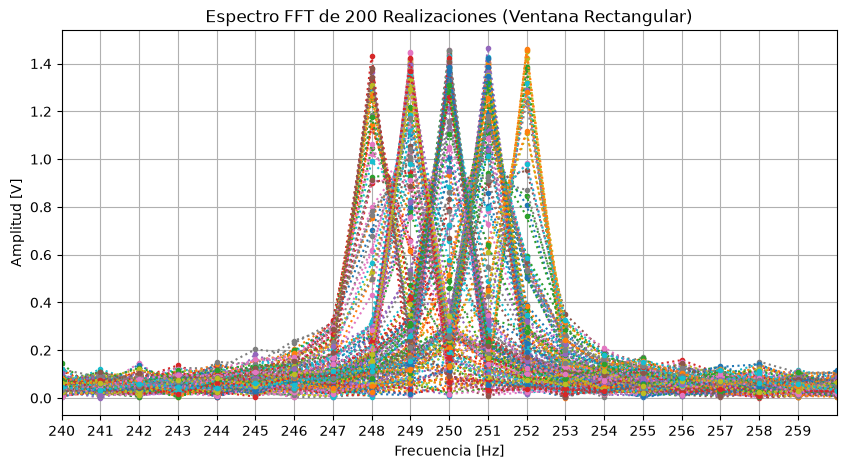

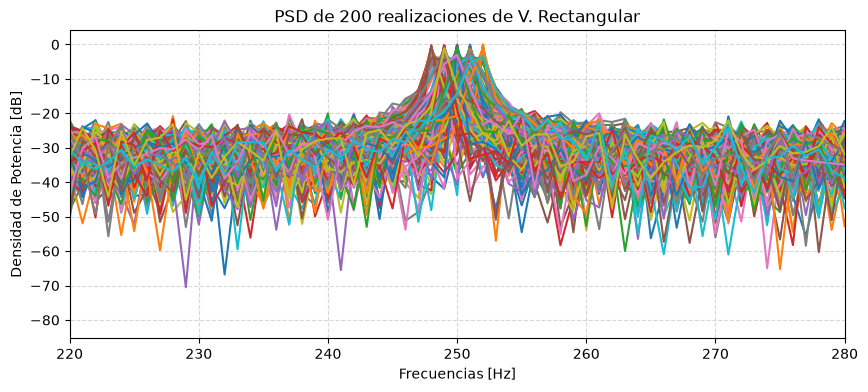

In [6]:
#la transformada de los 200 senos, cada uno de 1000 muestras>
#Se calcula con axis=0, ya que tengo N, R, para que haga la transformada a lo largo de N para cada una de las 200 realizaciones
# deberia obtener una matriz de 1000,200, pero limito N a N/2
fft_x1_rect = 2* np.abs(np.fft.fft(x1, axis=0) )[:N//2, :]/ N

# Eje de frecuencias para el grafico
Ts = 1/fs
frecuencias = np.fft.fftfreq(N, Ts)[:N//2] #de 0 a 500hz


################CHEQUEAR luego si debo multiplicar por 2, para otras TS tambien
# Gráfico de la FFT de las 200 realizaciones
plt.figure(figsize=(10, 5))
plt.plot(frecuencias, fft_x1_rect, ":.")
plt.xlim(240,260)
plt.xticks(np.arange(240, 260, 1))

plt.title("Espectro FFT de 200 Realizaciones (Ventana Rectangular)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.show()

############################################################## PSD EN DB
# Calculo de Potencia:
# modulo_fft_X   = np.abs(scipy.fft.fft(X)[:N//2]) / N
Max1 = np.max(fft_x1_rect)
PSD_X   = (fft_x1_rect /Max1)**2
PSD_X_db   = 10 * np.log10(PSD_X)


plt.figure(figsize = (10,4))
plt.plot(frecuencias, PSD_X_db, markersize=1.5)
plt.xlim(220, 280)
plt.title('PSD de 200 realizaciones de V. Rectangular')
plt.xlabel("Frecuencias [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



#LOS ESTIMADORES son vectores de dimension R, porque es 1 estimacion por cada realizacion
#Estimador de frecuencia Ω^i1, busca la frecuencia donde se encuentra la amplitud maxima

#np.max(fft_x1_rect, axis=0) me daria valor del maximo o sea la amplitud en voltios, no la posicion en el eje X, que es lo que busco con np.argmax
Omega_max = np.argmax(fft_x1_rect, axis=0) # me da un vector de 200 espacios y en cada espacio el bin de la frecuencia donde esta la amplitud maxima de las 500 (N/2) muestras o bins. O sea Recorre todas las realizaciones, y en cada una recorre N para que me devuelva el bin, donde se encuentra la ampltiud maxima 
#Estimador de frecuencia ef: Con el bin de la frecuencia obtenido, calculo cual es su frecuencia y obtengo un vector con las 200 frecuencias donde estan los maximos

#Frecuencias es el vector con las frecuencias de la señal, al evaluarle omega-max(los bins) me devuelve un vector con el valor de la frecuencia para cada bin que evaluo

#para comparar luego con el valor teorico de frecuencia angular digital: pi/2 radianes por muestra, debo pasar luego las frecuencias obtenidas en hz = 1/s  a radianes/muestra y por eso
#paso de hz a radianes
# y paso de 1/s a 1/muestra dividiendo por fs (en muestras por segundo) 

Ef_X1_rect = frecuencias[Omega_max]* (2 * np.pi / fs)

#Estimador de amplitud a^i1, mide la amplitud de la señal en la frecuencia Ω0, que es pi/2, o sea que con 1000 muestras, equivale al bin k=250
#Por lo tanto estima valor en amplitud en el bin 250 para todas las realizaciones. Mira la fila del bin  k = 250
Ea_X1_rect = fft_x1_rect[250, :]


#SESGO o bias : B(0) = E(O) - O
#El sesgo mide que tan lejos esta el promedio de las mediciones respecto al valor real. Calcula el promedio de las 200 y resta el valor teorico real

#VARIANZA
#Indica que tan dispersados estan los 200 resultados entre si, se obtiene realizando un promedio 


#SESGO Y VARIANZA DE AMPLTIDUD
media_a_x1_rect = np.mean(Ea_X1_rect)   # Promedio de las 200 amplitudes
sesgo_amp_X1rect = media_a_x1_rect - a0 # Sesgo de las 200 ampltidues. A0 = raiz de 2
var_amp_X1rect = np.var(Ea_X1_rect)     # Varianza de las 200 ampltidues

#SESGO Y VARIANZA DE FRECUENCIAS
media_v_x1_rect = np.mean(Ef_X1_rect)   # Promedio de las 200 frecuencias
ses_frec_X1rect = media_v_x1_rect - omega0 # Sesgo de las 200 frecuencias. omega0 es pi/2
var_frec_X1rect = np.var(Ef_X1_rect)     # Varianza de las 200 frecuencias

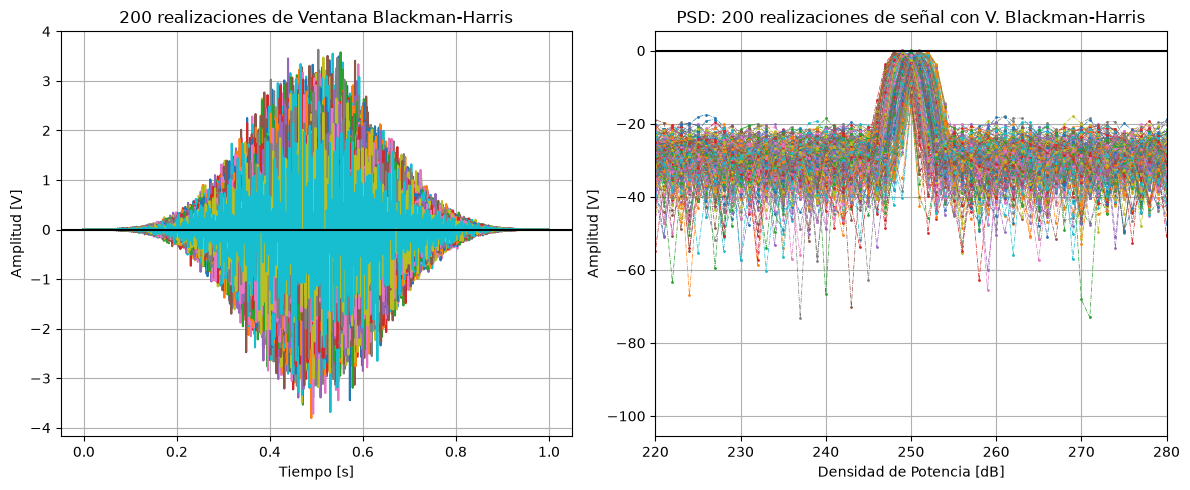

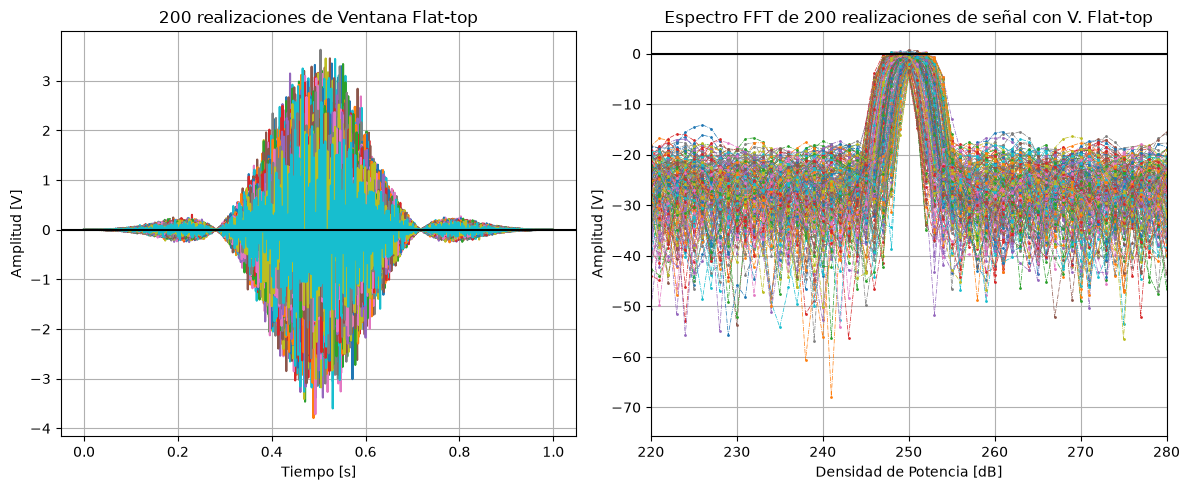

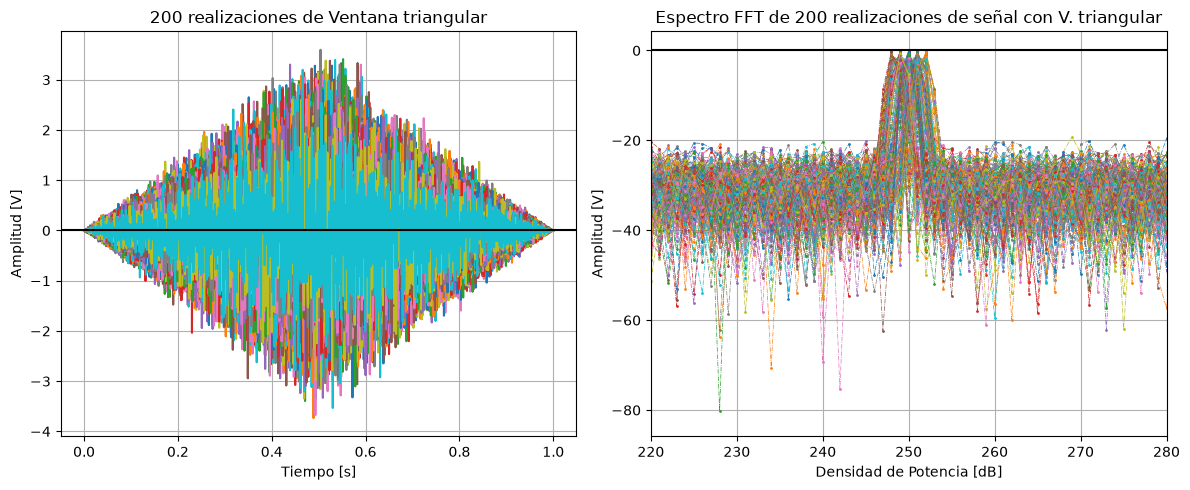

In [13]:
# %% Prosigo calculando sesgo y varianza para la señal x1 con las distintas ventanas:
import scipy.signal.windows as win
w_flattop = win.flattop(N).reshape(N, 1)
w_blackmanharris = win.blackmanharris(N).reshape(N, 1)
# Usare: ventana triangular
w_triang = win.triang(N).reshape(N,1)

# Aplicar la ventana a la señal temporal
x1_flattop = x1 * w_flattop
x1_bmh = x1 * w_blackmanharris
x1_triang = x1 * w_triang


# FFt de señal con ventanas, NORMALIZADA por la suma de 
fft_x1flat = 2 * np.abs(np.fft.fft(x1_flattop, axis=0))[:N//2, :] / np.sum(w_flattop)
fft_x1bmh = 2 * np.abs(np.fft.fft(x1_bmh, axis=0))[:N//2, :] / np.sum(w_blackmanharris)
fft_x1triang =  2 * np.abs(np.fft.fft(x1_triang, axis=0))[:N//2, :] / np.sum(w_triang)

#%% Grafico de señales con ventanas y sus PSD en db

PSD_Xflat   = (fft_x1flat /Max1)**2
PSD_X_dbflat   = 10 * np.log10(PSD_Xflat)

PSD_Xbmh   = (fft_x1bmh /Max1)**2
PSD_X_dbbmh   = 10 * np.log10(PSD_Xbmh)

PSD_Xtriang   = (fft_x1triang /Max1)**2
PSD_X_dbtriang   = 10 * np.log10(PSD_Xtriang)


#blacKMAN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t,x1_bmh)
plt.title("200 realizaciones de Ventana Blackman-Harris")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.subplot(1, 2, 2)

plt.plot(frecuencias,PSD_X_dbbmh, ls = '-.', linewidth=0.5, marker='o', markersize=1)
plt.title("PSD: 200 realizaciones de señal con V. Blackman-Harris")
plt.ylabel("Amplitud [V]")
plt.xlabel("Densidad de Potencia [dB]")
plt.xlim(220, 280)
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.tight_layout()
plt.show()


#FLAT TOP
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t,x1_flattop)
plt.title("200 realizaciones de Ventana Flat-top")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.subplot(1, 2, 2)

plt.plot(frecuencias,PSD_X_dbflat, ls = '-.', linewidth=0.5, marker='o', markersize=1)
plt.title("Espectro FFT de 200 realizaciones de señal con V. Flat-top")
plt.ylabel("Amplitud [V]")
plt.xlabel("Densidad de Potencia [dB]")
plt.xlim(220, 280)
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.tight_layout()
plt.show()

#TRIANGULAR
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t,x1_triang)
plt.title("200 realizaciones de Ventana triangular")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.subplot(1, 2, 2)

plt.plot(frecuencias,PSD_X_dbtriang, ls = '-.', linewidth=0.5, marker='o', markersize=1)
plt.title("Espectro FFT de 200 realizaciones de señal con V. triangular")
plt.ylabel("Amplitud [V]")
plt.xlabel("Densidad de Potencia [dB]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.xlim(220, 280)
plt.tight_layout()
plt.show()

In [16]:
# Defino Una funcion para calcular sesgo y varianaza de ampitud y de frecuencia a partir de cada fft (N, R)
def calcular_sesgo_varianza_fft(fft, frecuencias = frecuencias, valor_teorico_frecuencia = omega0, fs=fs,  val_teorico_amplitud=a0, k = 250):
    
    
    #estimador de amplitud 
    Ea = fft[k, :]
    #estimador de frecuencia
    Bin_fmax = np.argmax(fft, axis=0)
    Ef = frecuencias[Bin_fmax ]* (2 * np.pi / fs)

    media_amplitud= np.mean(Ea)
    sesgo_amplitud = media_amplitud - val_teorico_amplitud
    varianza_ampltiud = np.var(Ea)
    
    media_frecuencia= np.mean(Ef)
    sesgo_frecuencia = media_frecuencia - valor_teorico_frecuencia
    varianza_frecuencia = np.var(Ef)
    
    return sesgo_amplitud, varianza_ampltiud, sesgo_frecuencia, varianza_frecuencia, Ea, Ef
#estimadores de flattop
ses_amp_x1flat, var_amp_x1flat, ses_frec_x1flat, var_frec_x1flat, Ea_x1flat, Ef_x1flat               = calcular_sesgo_varianza_fft(fft = fft_x1flat)

#estimadores de blackman harris
ses_amp_x1bmh, var_amp_x1bmh, ses_frec_x1bmh, var_frec_x1bmh, Ea_x1bmh, Ef_x1bmh                     = calcular_sesgo_varianza_fft(fft = fft_x1bmh)

#estimadores de flattop
ses_amp_x1triang, var_amp_x1triang, ses_frec_x1triang, var_frec_x1triang, Ea_x1triang, Ef_x1triang    = calcular_sesgo_varianza_fft(fft = fft_x1triang)

#imprimo tablas para señal X1 con SNR = 3db

# TABLA: SESGO Y VARIANZA DE AMPLITUD
print("-" * 65)
print("SEÑAL: X1, SNR = 3db (AMPLITUD)")
print("-" * 65)
print(f"{'VENTANA':<18} | {'SESGO AMPLITUD':<20} | {'VARIANZA AMPLITUD'}")
print("-" * 65)
print(f"{'Rectangular':<18} | {sesgo_amp_X1rect:<20.6f} | {var_amp_X1rect:.6f}")
print(f"{'Flattop':<18} | {ses_amp_x1flat:<20.6f} | {var_amp_x1flat:.6f}")
print(f"{'Blackman-Harris':<18} | {ses_amp_x1bmh:<20.6f} | {var_amp_x1bmh:.6f}")
print(f"{'Triangular':<18} | {ses_amp_x1triang:<20.6f} | {var_amp_x1triang:.6f}")
print("\n")


# TABLA: SESGO Y VARIANZA DE FRECUENCIA 
print("-" * 65)
print("SEÑAL: X1, SNR = 3db (FRECUENCIA)")
print("-" * 65)
print(f"{'VENTANA':<18} | {'SESGO FRECUENCIA':<20} | {'VARIANZA FRECUENCIA'}")
print("-" * 65)
print(f"{'Rectangular':<18} | {ses_frec_X1rect:<20.6f} | {var_frec_X1rect:.6f}")
print(f"{'Flattop':<18} | {ses_frec_x1flat:<20.6f} | {var_frec_x1flat:.6f}")
print(f"{'Blackman-Harris':<18} | {ses_frec_x1bmh:<20.6f} | {var_frec_x1bmh:.6f}")
print(f"{'Triangular':<18} | {ses_frec_x1triang:<20.6f} | {var_frec_x1triang:.6f}")
print("\n")

-----------------------------------------------------------------
SEÑAL: X1, SNR = 3db (AMPLITUD)
-----------------------------------------------------------------
VENTANA            | SESGO AMPLITUD       | VARIANZA AMPLITUD
-----------------------------------------------------------------
Rectangular        | -0.887144            | 0.231797
Flattop            | -0.111910            | 0.021615
Blackman-Harris    | -0.468203            | 0.126849
Triangular         | -0.747359            | 0.242841


-----------------------------------------------------------------
SEÑAL: X1, SNR = 3db (FRECUENCIA)
-----------------------------------------------------------------
VENTANA            | SESGO FRECUENCIA     | VARIANZA FRECUENCIA
-----------------------------------------------------------------
Rectangular        | 0.000031             | 0.000052
Flattop            | -0.000188            | 0.000054
Blackman-Harris    | -0.000094            | 0.000051
Triangular         | -0.000031         

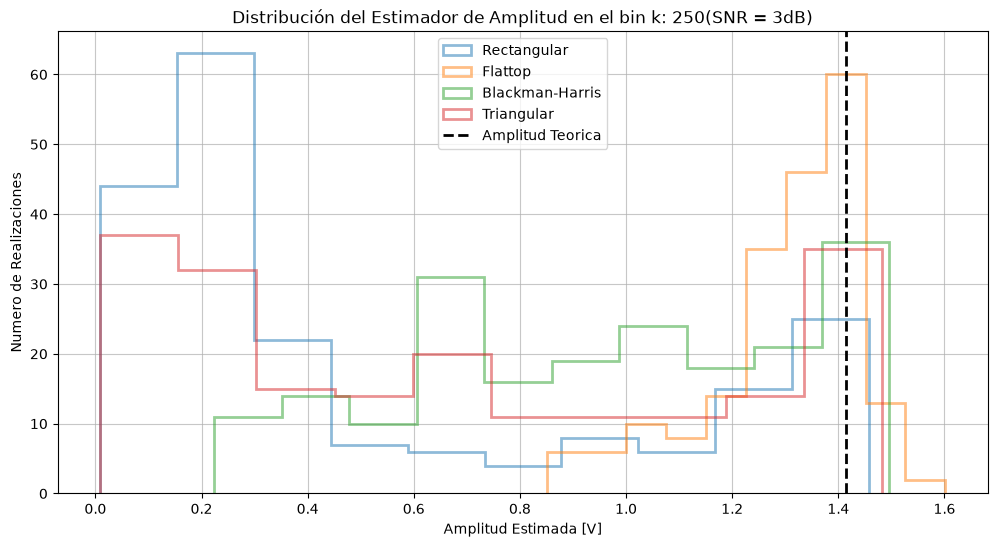

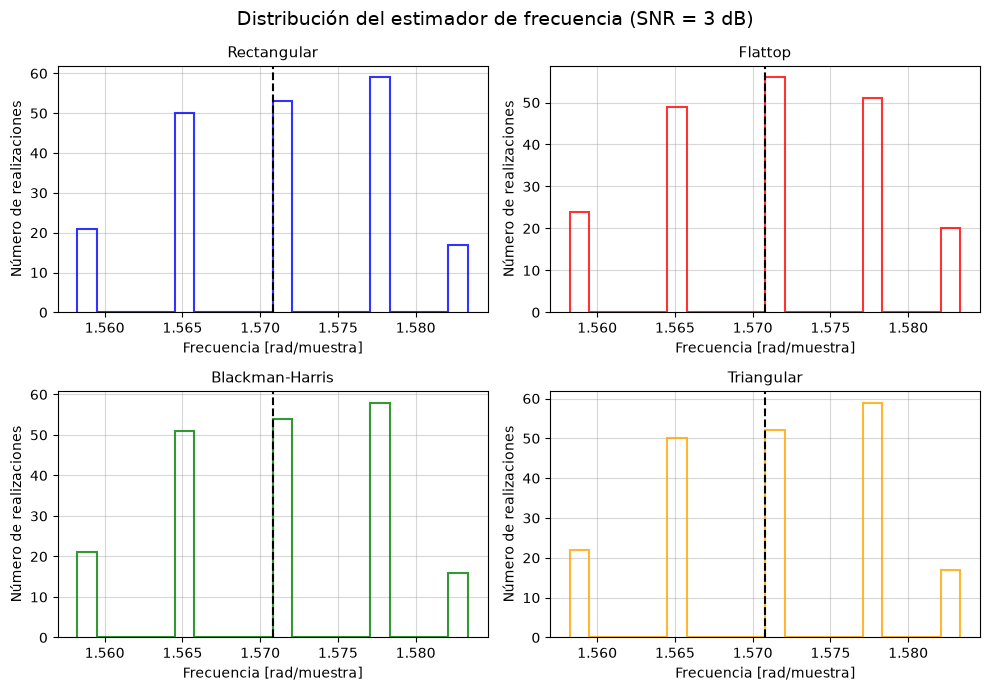

In [28]:
# %% Histograma de Amplitud para SNR 3dB 

#grafico que meustra el numero de realizaciones para cada valor(o rango de valor) de amplitud medido 

plt.figure(figsize=(12, 6))
plt.hist(Ea_X1_rect, bins=10, alpha=0.5, label='Rectangular', histtype='step', linewidth=2)
plt.hist(Ea_x1flat, bins=10, alpha=0.5, label='Flattop', histtype='step', linewidth=2)
plt.hist(Ea_x1bmh, bins=10, alpha=0.5, label='Blackman-Harris', histtype='step', linewidth=2)
plt.hist(Ea_x1triang, bins=10, alpha=0.5, label='Triangular', histtype='step', linewidth=2)

plt.axvline(np.sqrt(2), color='k', linestyle='dashed', linewidth=2, label='Amplitud Teorica')

plt.title("Distribución del Estimador de Amplitud en el bin k: 250(SNR = 3dB)")
plt.xlabel("Amplitud Estimada [V]")
plt.ylabel("Numero de Realizaciones")
plt.legend()
plt.grid(True, alpha=0.7)
plt.show()

# Histograma de frecuencia para SNR 3dB 

#grafico que meustra el numero de realizaciones para cada valor(o rango de valor) de frecuencia medido 
fig, axs = plt.subplots(2, 2, figsize=(10, 7))

# Rectangular
axs[0, 0].hist(Ef_X1_rect, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='blue')
axs[0, 0].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[0, 0].set_title('Rectangular', fontsize=11)
axs[0, 0].set_xlabel('Frecuencia [rad/muestra]')
axs[0, 0].set_ylabel('Número de realizaciones')
axs[0, 0].grid(True, alpha=0.5)

# Flattop
axs[0, 1].hist(Ef_x1flat, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='red')
axs[0, 1].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[0, 1].set_title('Flattop', fontsize=11)
axs[0, 1].set_xlabel('Frecuencia [rad/muestra]')
axs[0, 1].set_ylabel('Número de realizaciones')
axs[0, 1].grid(True, alpha=0.5)

# Blackman-Harris
axs[1, 0].hist(Ef_x1bmh, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='green')
axs[1, 0].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[1, 0].set_title('Blackman-Harris', fontsize=11)
axs[1, 0].set_xlabel('Frecuencia [rad/muestra]')
axs[1, 0].set_ylabel('Número de realizaciones')
axs[1, 0].grid(True, alpha=0.5)

# Triangular
axs[1, 1].hist(Ef_x1triang, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='orange')
axs[1, 1].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[1, 1].set_title('Triangular', fontsize=11)
axs[1, 1].set_xlabel('Frecuencia [rad/muestra]')
axs[1, 1].set_ylabel('Número de realizaciones')
axs[1, 1].grid(True, alpha=0.5)

# Título general
fig.suptitle(
    'Distribución del estimador de frecuencia (SNR = 3 dB)',
    fontsize=14
)

plt.tight_layout()
plt.show()


In [26]:
# %% para snr = 10

SNR2 = 10
Pruido2 =(Psen)/(10**(SNR2/10))
Var2 = Pruido2
Na2 = np.random.normal(0, np.sqrt(Var2), size=(N, R))

#señal con snr = 10
x2 = a0 * np.sin(n * omega1) + Na2


# Aplicar la ventana a la señal temporal
x2_flattop = x2 * w_flattop
x2_bmh =     x2 * w_blackmanharris
x2_triang = x2 * w_triang

fft_x2rect = 2* np.abs(np.fft.fft(x2, axis=0) )[:N//2, :]/ N
fft_x2flattop = 2* np.abs(np.fft.fft(x2_flattop, axis=0) )[:N//2, :]/ np.sum(w_flattop)
fft_x2bmh = 2* np.abs(np.fft.fft(x2_bmh , axis=0) )[:N//2, :]/np.sum(w_blackmanharris)
fft_x2triang = 2* np.abs(np.fft.fft(x2_triang , axis=0) )[:N//2, :]/np.sum(w_triang)

#estimadores de rectangular
ses_amp_x2, var_amp_x2, ses_frec_x2, var_frec_x2, Ea_x2, Ef_x2  = calcular_sesgo_varianza_fft(fft = fft_x2rect)
#estimadores de flattop
ses_amp_x2flat, var_amp_x2flat, ses_frec_x2flat, var_frec_x2flat, Ea_x2flat, Ef_x2flat  = calcular_sesgo_varianza_fft(fft = fft_x2flattop)
#estimadores de blackman harris
ses_amp_x2bmh, var_amp_x2bmh, ses_frec_x2bmh, var_frec_x2bmh, Ea_x2bmh, Ef_x2bmh  = calcular_sesgo_varianza_fft(fft = fft_x2bmh)
#estimadores de flattop
ses_amp_x2triang, var_amp_x2triang, ses_frec_x2triang, var_frec_x2triang, Ea_x2triang, Ef_x2triang  = calcular_sesgo_varianza_fft(fft = fft_x2triang)


#imprimo tablas para señal X1 con SNR = 3db
# TABLA: SESGO Y VARIANZA DE AMPLITUDde x2
print("-" * 65)
print("SEÑAL: X2, SNR = 10db (AMPLITUD)")
print("-" * 65)
print(f"{'VENTANA':<18} | {'SESGO AMPLITUD':<20} | {'VARIANZA AMPLITUD'}")
print("-" * 65)
print(f"{'Rectangular':<18} | {ses_amp_x2:<20.6f} | {var_amp_x2:.6f}")
print(f"{'Flattop':<18} | {ses_amp_x2flat:<20.6f} | {var_amp_x2flat:.6f}")
print(f"{'Blackman-Harris':<18} | {ses_amp_x2bmh:<20.6f} | {var_amp_x2bmh:.6f}")
print(f"{'Triangular':<18} | {ses_amp_x2triang:<20.6f} | {var_amp_x2triang:.6f}")
print("\n")


# TABLA: SESGO Y VARIANZA DE FRECUENCIA x2
print("-" * 65)
print("SEÑAL: X2, SNR = 10db (FRECUENCIA)")
print("-" * 65)
print(f"{'VENTANA':<18} | {'SESGO FRECUENCIA':<20} | {'VARIANZA FRECUENCIA'}")
print("-" * 65)
print(f"{'Rectangular':<18} | {ses_frec_x2:<20.6f} | {var_frec_x2:.6f}")
print(f"{'Flattop':<18} | {ses_frec_x2flat:<20.6f} | {var_frec_x2flat:.6f}")
print(f"{'Blackman-Harris':<18} | {ses_frec_x2bmh:<20.6f} | {var_frec_x2bmh:.6f}")
print(f"{'Triangular':<18} | {ses_frec_x2triang:<20.6f} | {var_frec_x2triang:.6f}")
print("\n")


-----------------------------------------------------------------
SEÑAL: X2, SNR = 10db (AMPLITUD)
-----------------------------------------------------------------
VENTANA            | SESGO AMPLITUD       | VARIANZA AMPLITUD
-----------------------------------------------------------------
Rectangular        | -0.887337            | 0.232110
Flattop            | -0.106920            | 0.019840
Blackman-Harris    | -0.464103            | 0.126875
Triangular         | -0.749591            | 0.249386


-----------------------------------------------------------------
SEÑAL: X2, SNR = 10db (FRECUENCIA)
-----------------------------------------------------------------
VENTANA            | SESGO FRECUENCIA     | VARIANZA FRECUENCIA
-----------------------------------------------------------------
Rectangular        | 0.000031             | 0.000052
Flattop            | 0.000000             | 0.000056
Blackman-Harris    | -0.000031            | 0.000052
Triangular         | 0.000000        

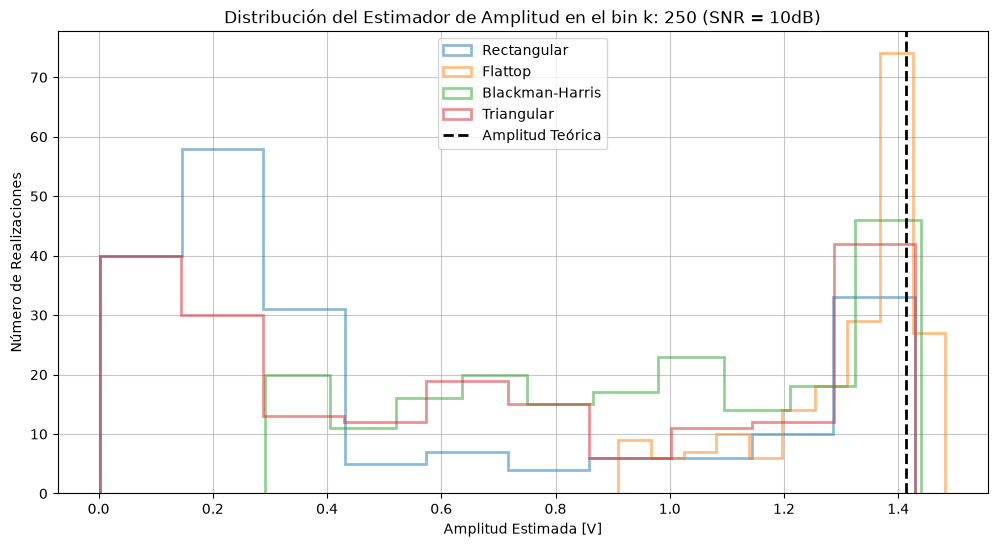

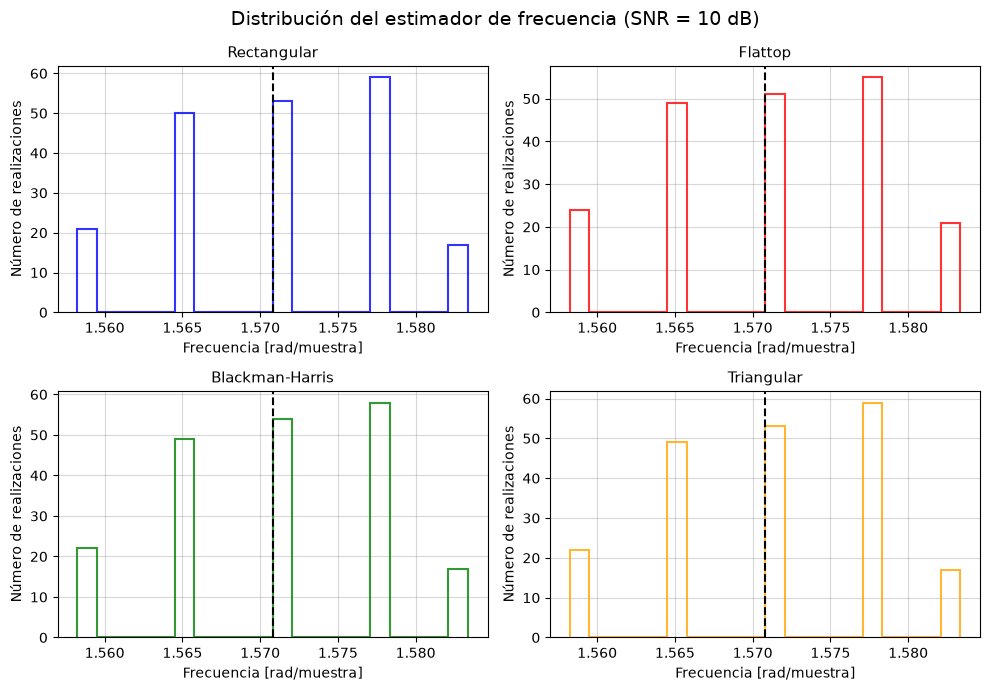

In [29]:

# %% Histograma de Amplitud para SNR = 10 dB
plt.figure(figsize=(12, 6))
plt.hist(Ea_x2, bins=10, alpha=0.5, label='Rectangular', histtype='step', linewidth=2)
plt.hist(Ea_x2flat, bins=10, alpha=0.5, label='Flattop', histtype='step', linewidth=2)
plt.hist(Ea_x2bmh, bins=10, alpha=0.5, label='Blackman-Harris', histtype='step', linewidth=2)
plt.hist(Ea_x2triang, bins=10, alpha=0.5, label='Triangular', histtype='step', linewidth=2)

plt.axvline(np.sqrt(2), color='k', linestyle='dashed', linewidth=2, label='Amplitud Teórica')

plt.title("Distribución del Estimador de Amplitud en el bin k: 250 (SNR = 10dB)")
plt.xlabel("Amplitud Estimada [V]")
plt.ylabel("Número de Realizaciones")
plt.legend()
plt.grid(True, alpha=0.7)
plt.show()

# Histograma de Frecuencia para SNR = 10 dB


# Histogramas de Frecuencia para SNR = 10 dB

fig, axs = plt.subplots(2, 2, figsize=(10, 7))

# Rectangular
axs[0, 0].hist(Ef_x2, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='blue')
axs[0, 0].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[0, 0].set_title('Rectangular', fontsize=11)
axs[0, 0].set_xlabel('Frecuencia [rad/muestra]')
axs[0, 0].set_ylabel('Número de realizaciones')
axs[0, 0].grid(True, alpha=0.5)

# Flattop
axs[0, 1].hist(Ef_x2flat, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='red')
axs[0, 1].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[0, 1].set_title('Flattop', fontsize=11)
axs[0, 1].set_xlabel('Frecuencia [rad/muestra]')
axs[0, 1].set_ylabel('Número de realizaciones')
axs[0, 1].grid(True, alpha=0.5)

# Blackman-Harris
axs[1, 0].hist(Ef_x2bmh, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='green')
axs[1, 0].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[1, 0].set_title('Blackman-Harris', fontsize=11)
axs[1, 0].set_xlabel('Frecuencia [rad/muestra]')
axs[1, 0].set_ylabel('Número de realizaciones')
axs[1, 0].grid(True, alpha=0.5)

# Triangular
axs[1, 1].hist(Ef_x2triang, bins=20, alpha=0.8,
               histtype='step', linewidth=1.5, color='orange')
axs[1, 1].axvline(np.pi / 2, color='black',
                  linestyle='--', linewidth=1.5)
axs[1, 1].set_title('Triangular', fontsize=11)
axs[1, 1].set_xlabel('Frecuencia [rad/muestra]')
axs[1, 1].set_ylabel('Número de realizaciones')
axs[1, 1].grid(True, alpha=0.5)

# Título general
fig.suptitle(
    'Distribución del estimador de frecuencia (SNR = 10 dB)',
    fontsize=14
)

plt.tight_layout()
plt.show()
